### CROMA embeddings per FID

In [29]:
import os
import glob
import numpy as np
import torch
import rasterio
import matplotlib.pyplot as plt
from torchgeo.models import croma_base, CROMABase_Weights

TILES_DIR = os.path.expanduser("~/thesis_tiles_120px")

PATCH_SIZE = 8
EMBED_DIM = 768
TILE_SIZE = 120
GRID_SIZE = TILE_SIZE // PATCH_SIZE     # 15
CROMA_S2_BAND_INDICES = list(range(12))

device = torch.device("cuda" if torch.cuda.is_available()
                      else "mps" if torch.backends.mps.is_available()
                      else "cpu")
print(f"Device: {device}")
print(f"Tiles dir: {TILES_DIR}")

#find the tiles in the folder
def find_all_tiles(fid, product, window, image_id):
    pattern = os.path.join(TILES_DIR, product, f"fid_{fid}", window, image_id, "tile_*.tif")
    return sorted(glob.glob(pattern))

#images names
def list_image_ids(fid, product, window):
    win_dir = os.path.join(TILES_DIR, product, f"fid_{fid}", window)
    if not os.path.isdir(win_dir):
        return []
    return sorted(os.listdir(win_dir))


Device: cuda
Tiles dir: /share/home/e2406749/thesis_tiles_120px


In [30]:
#load one tile
def load_tile(path, band_indices=None):
    with rasterio.open(path) as src:
        data = src.read().astype(np.float32)
    if band_indices is not None:
        data = data[band_indices]
    return data


def normalize(x, mean, std):
    """CROMA recipe with global stats: clip to mean ± 2*std per channel, rescale to [0, 1].

    x:    (N, C, H, W) tensor
    mean: (C,) tensor or array
    std:  (C,) tensor or array
    """
    x = x.float()
    mean = torch.as_tensor(mean, dtype=x.dtype, device=x.device).view(1, -1, 1, 1)
    std = torch.as_tensor(std, dtype=x.dtype, device=x.device).view(1, -1, 1, 1)
    min_val = mean - 2 * std
    max_val = mean + 2 * std
    x = (x - min_val) / (max_val - min_val)
    return torch.clamp(x, 0, 1)


def encode(model, x_normalized, modality):
    """Forward pass on a normalized batch. Returns (N, 15, 15, 768) tokens."""
    captured = {}
    encoder = model.s2_encoder if modality == "optical" else model.s1_encoder

    def hook(module, inp, out):
        captured["tokens"] = out

    h = encoder.register_forward_hook(hook)
    with torch.no_grad():
        if modality == "optical":
            _ = model(x_optical=x_normalized)
        else:
            _ = model(x_sar=x_normalized)
    h.remove()

    out = captured["tokens"]
    if isinstance(out, tuple):
        out = out[0]
    tokens = out.cpu().numpy()
    if tokens.ndim == 2:
        tokens = tokens[None]
    expected = GRID_SIZE * GRID_SIZE
    if tokens.shape[1] == expected + 1:
        tokens = tokens[:, 1:]
    return tokens.reshape(-1, GRID_SIZE, GRID_SIZE, EMBED_DIM)


Check the max and min of Sentinel 1 and Sentinel 2

In [31]:
 # Carga una tile de S1 y mira el rango
for product, bands in [("s2_l2a", list(range(12))), ("s1_grd", [0, 1])]:
      paths = glob.glob(os.path.join(TILES_DIR, product, "fid_*", "*", "*", "tile_*.tif"))
      arr = np.stack([load_tile(p, band_indices=bands) for p in paths])  # (N, C, H, W)
      print(f"\n{product}  ({len(paths)} tiles)")
      for c in range(arr.shape[1]):
          ch = arr[:, c]
          print(f"  band {c}: min={ch.min():.3f}  max={ch.max():.3f}  mean={ch.mean():.3f}")


s2_l2a  (1572 tiles)
  band 0: min=26.000  max=14232.000  mean=411.348
  band 1: min=0.000  max=14328.000  mean=407.982
  band 2: min=0.000  max=13040.000  mean=552.304
  band 3: min=0.000  max=12496.000  mean=390.610
  band 4: min=76.000  max=12996.000  mean=851.709
  band 5: min=0.000  max=12280.000  mean=2229.991
  band 6: min=0.000  max=11821.000  mean=2813.341
  band 7: min=0.000  max=11960.000  mean=2810.892
  band 8: min=0.000  max=11324.000  mean=3138.849
  band 9: min=0.000  max=17342.000  mean=3144.938
  band 10: min=4.000  max=15986.000  mean=1735.651
  band 11: min=14.000  max=15651.000  mean=825.237

s1_grd  (1697 tiles)
  band 0: min=-40.256  max=7.763  mean=-7.930
  band 1: min=-50.181  max=2.777  mean=-13.937


In [32]:
# Per-channel global mean/std over ALL tiles of a product
# (all FIDs, all windows, all image_ids). Streams tiles to keep memory bounded.
def compute_global_stats(product, band_indices, min_valid=None, max_valid=None):
      pattern = os.path.join(TILES_DIR, product, "fid_*", "*", "*", "tile_*.tif")
      paths = glob.glob(pattern)
      if not paths:
          raise FileNotFoundError(f"No tiles matched: {pattern}")

      C = len(band_indices)
      sum_   = np.zeros(C, dtype=np.float64)
      sum_sq = np.zeros(C, dtype=np.float64)
      count  = np.zeros(C, dtype=np.int64)

      for p in paths:
          data = load_tile(p, band_indices=band_indices)
          valid = np.isfinite(data)
          if min_valid is not None: # diferent for s1 and s2
              valid &= (data > min_valid)
          if max_valid is not None:
              valid &= (data < max_valid)
          d = np.where(valid, data, 0.0).astype(np.float64)
          sum_   += d.sum(axis=(1, 2))
          sum_sq += (d * d).sum(axis=(1, 2))
          count  += valid.sum(axis=(1, 2)).astype(np.int64)

      mean = sum_ / np.maximum(count, 1)
      var  = sum_sq / np.maximum(count, 1) - mean ** 2
      std  = np.sqrt(np.maximum(var, 0.0))
      return mean.astype(np.float32), std.astype(np.float32), len(paths)


In [33]:
# Compute global stats once per kernel — used for normalization in the run cell.
s2_mean, s2_std, n_s2 = compute_global_stats("s2_l2a", list(range(12)), min_valid=0)
print(f"S2 stats over {n_s2} tiles  (12 bands)")
print(f"  mean: {np.array2string(s2_mean, precision=2)}")
print(f"  std : {np.array2string(s2_std,  precision=2)}")

s1_mean, s1_std, n_s1 = compute_global_stats("s1_grd", [0, 1])
print(f"\nS1 stats over {n_s1} tiles  (VV, VH)")
print(f"  mean: {np.array2string(s1_mean, precision=2)}")
print(f"  std : {np.array2string(s1_std,  precision=2)}")


S2 stats over 1572 tiles  (12 bands)
  mean: [ 411.35  407.98  552.3   390.61  851.71 2230.04 2813.42 2810.98 3138.97 3144.96 1735.65  825.24]
  std : [469.89 459.83 415.99 412.51 419.18 519.92 616.25 657.82 653.43 662.87 499.25 451.38]

S1 stats over 1697 tiles  (VV, VH)
  mean: [ -7.93 -13.94]
  std : [2.94 3.8 ]


In [34]:
model = croma_base(
    weights=CROMABase_Weights.CROMA_VIT,
    modalities=["optical"],
    image_size=TILE_SIZE,
).to(device).eval()
print("CROMA optical model loaded")


CROMA optical model loaded


In [35]:
FID = "153"           # adjust to any FID you have on disk
WINDOW = "bef"        # bef / evt / aft
PRODUCT = "s2_l2a"
MODALITY = "optical"

# 1) Pick first available acquisition for this (FID, window)
image_ids = list_image_ids(FID, PRODUCT, WINDOW)
assert image_ids, f"No image_ids for fid={FID} {WINDOW}"
image_id = image_ids[0]
paths = find_all_tiles(FID, PRODUCT, WINDOW, image_id)
print(f"FID={FID}  window={WINDOW}  image_id={image_id}")
print(f"Tiles found: {len(paths)}")

# 2) Load all tiles and stack into a batch (N, C, H, W)
# N = number of tiles
# C = number of bands
# H = height
# W = width
band_indices = CROMA_S2_BAND_INDICES if MODALITY == "optical" else [0, 1]
all_data = np.stack(
    [load_tile(p, band_indices=band_indices) for p in paths],
    axis=0,
).astype(np.float32)
print(f"Batch shape: {all_data.shape}")

FID=153  window=bef  image_id=20230214T142711_20230214T143425_T20LNR
Tiles found: 4
Batch shape: (4, 12, 120, 120)


### Q3 — draw the S2 mosaic before vs after normalization.

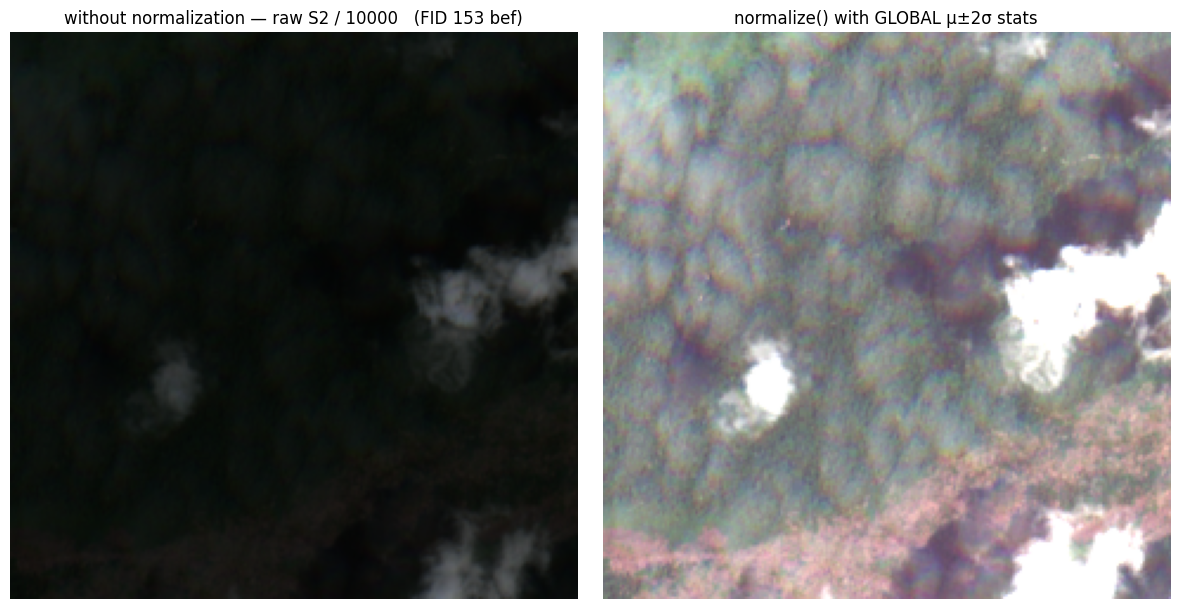

In [36]:
TILE_SIZE_M = TILE_SIZE * 10   # 1200 m per tile

transforms = []
for p in paths:
    with rasterio.open(p) as src:
        transforms.append(src.transform)

cs = [t.c for t in transforms]
fs = [t.f for t in transforms]
x0 = min(cs)
y0 = max(fs)
n_cols = int(round((max(cs) - x0) / TILE_SIZE_M)) + 1
n_rows = int(round((y0 - min(fs)) / TILE_SIZE_M)) + 1

# 1) Build a RAW data mosaic of shape (12, n_rows*120, n_cols*120) using the
#    same tile-grid placement that viz_dims uses for the embeddings mosaic.
data_mosaic = np.full((12, n_rows * TILE_SIZE, n_cols * TILE_SIZE),
                    np.nan, dtype=np.float32)
for i, p in enumerate(paths):
    with rasterio.open(p) as src:
        t = src.transform
    row = int(round((y0 - t.f) / TILE_SIZE_M))
    col = int(round((t.c - x0) / TILE_SIZE_M))
    data_mosaic[:, row * TILE_SIZE:(row + 1) * TILE_SIZE,
                    col * TILE_SIZE:(col + 1) * TILE_SIZE] = all_data[i]

# 2) Apply normalize() with GLOBAL stats to the batch, then mosaic the result.
x_norm = normalize(torch.from_numpy(all_data), s2_mean, s2_std).cpu().numpy()
norm_mosaic = np.full_like(data_mosaic, np.nan)
for i, p in enumerate(paths):
    with rasterio.open(p) as src:
        t = src.transform
    row = int(round((y0 - t.f) / TILE_SIZE_M))
    col = int(round((t.c - x0) / TILE_SIZE_M))
    norm_mosaic[:, row * TILE_SIZE:(row + 1) * TILE_SIZE,
                    col * TILE_SIZE:(col + 1) * TILE_SIZE] = x_norm[i]

# 3) Pull RGB = (B4, B3, B2) = bands (3, 2, 1) for both versions.
#    BEFORE: divide by 10000 (S2 L2A scale factor) and clip to [0, 1].
rgb_before = np.clip(data_mosaic[[3, 2, 1]].transpose(1, 2, 0) / 10000, 0, 1)
#    AFTER: already in [0, 1] from normalize(), just transpose to HWC.
rgb_after  = norm_mosaic[[3, 2, 1]].transpose(1, 2, 0)

# 4) Plot side by side.
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(np.where(np.isnan(rgb_before), 0.5, rgb_before))
axes[0].set_title(f"without normalization — raw S2 / 10000   (FID {FID} {WINDOW})")
axes[0].axis("off")
axes[1].imshow(np.where(np.isnan(rgb_after), 0.5, rgb_after))
axes[1].set_title("normalize() with GLOBAL μ±2σ stats")
axes[1].axis("off")
plt.tight_layout()
plt.show()

In [37]:
# 3) Normalize with GLOBAL stats (computed over all S2/S1 tiles) and encode
mean = s2_mean if MODALITY == "optical" else s1_mean
std  = s2_std  if MODALITY == "optical" else s1_std
x = torch.from_numpy(all_data)
x = normalize(x, mean, std).to(device)
tokens = encode(model, x, MODALITY)        # (N, 15, 15, 768)
print(f"Tokens shape: {tokens.shape}")


Tokens shape: (4, 15, 15, 768)


In [38]:
# Print values of ONE embedding dimension across all patches of all tiles.
DIM = 0   # pick any dimension in [0, 767]

print(f"Values of dimension {DIM} for each tile (15x15 grid of patches):\n")
for i, t in enumerate(tokens):
    print(f"--- tile {i} (path: {os.path.basename(paths[i])}) ---")
    # t has shape (15, 15, 768); slice the chosen dimension
    plane = t[:, :, DIM]
    np.set_printoptions(precision=3, suppress=True, linewidth=160)
    print(plane)
    print()


Values of dimension 0 for each tile (15x15 grid of patches):

--- tile 0 (path: tile_0.tif) ---
[[-0.93  -0.933 -1.205 -1.326 -0.383 -2.019 -2.415 -1.984 -2.816 -2.122 -1.876 -1.302 -0.458 -0.924 -0.555]
 [-0.965 -1.617 -1.123 -2.658  0.152 -1.029 -1.973 -1.466 -0.75  -0.401 -1.707 -1.506 -0.735  0.036 -0.795]
 [-0.396 -1.153 -1.426 -2.018 -0.009 -0.163 -1.903 -1.591 -1.421 -1.17  -1.979 -1.891 -0.868 -0.852 -0.678]
 [-1.263 -0.965 -1.78  -2.323  0.227 -1.55  -1.522 -0.701 -1.493 -1.185 -1.651 -1.086 -0.33  -0.291 -0.245]
 [-0.884 -1.282 -1.709 -1.994 -1.175 -2.734 -1.814 -1.817 -2.048 -0.985 -1.109 -0.584 -0.25  -0.72  -0.528]
 [-0.452 -0.626 -1.4   -2.141 -2.296 -1.628 -1.916 -1.955 -1.672 -1.425 -0.673 -0.662 -1.118 -0.574 -0.542]
 [-0.417 -0.867 -1.199 -1.504 -2.272 -1.731 -1.635 -1.54  -1.308 -0.979 -1.988 -0.855  0.045 -0.423 -1.567]
 [-1.201 -1.079 -0.749 -1.187 -1.224 -0.939 -1.49  -1.255 -1.185 -1.714 -1.099 -1.483 -1.175 -0.237 -1.12 ]
 [-0.838 -1.957 -1.116 -1.175 -0.702 -0.

Mosaic: 2x2 tiles -> token grid (30, 30, 768)
Per-dim min range: [-4.848, 0.008]
Per-dim max range: [0.381, 4.615]


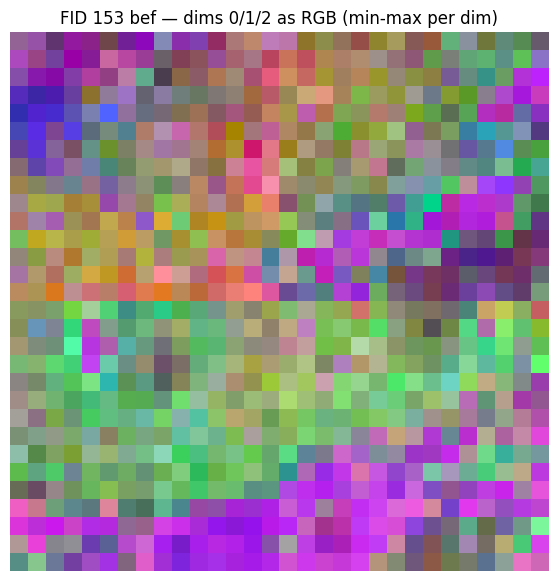

In [39]:
# Stitch tile tokens into a mosaic using each tile's geo-coordinates.
mosaic = np.full((n_rows * GRID_SIZE, n_cols * GRID_SIZE, EMBED_DIM), np.nan, dtype=np.float32)
for i, p in enumerate(paths):
    with rasterio.open(p) as src:
        t = src.transform
    row = int(round((y0 - t.f) / TILE_SIZE_M))
    col = int(round((t.c - x0) / TILE_SIZE_M))
    mosaic[row * GRID_SIZE:(row + 1) * GRID_SIZE,
           col * GRID_SIZE:(col + 1) * GRID_SIZE, :] = tokens[i]

print(f"Mosaic: {n_rows}x{n_cols} tiles -> token grid {mosaic.shape}")

# Global min/max per embedding dimension across ALL valid patches in the mosaic
flat = mosaic.reshape(-1, EMBED_DIM)
valid_mask = ~np.isnan(flat).any(axis=1)
d_min = flat[valid_mask].min(axis=0)     # shape (768,)
d_max = flat[valid_mask].max(axis=0)     # shape (768,)
print(f"Per-dim min range: [{d_min.min():.3f}, {d_min.max():.3f}]")
print(f"Per-dim max range: [{d_max.min():.3f}, {d_max.max():.3f}]")

# Min-max normalize: I_norm = (I - I_min) / (I_max - I_min)
mosaic_norm = (mosaic - d_min) / (d_max - d_min)

# Plot the first 3 dimensions as RGB
rgb = mosaic_norm[:, :, :3]
rgb_disp = np.where(np.isnan(rgb), 0.5, rgb)

plt.figure(figsize=(7, 7))
plt.imshow(rgb_disp, interpolation="nearest")
plt.title(f"FID {FID} {WINDOW} — dims 0/1/2 as RGB (min-max per dim)")
plt.axis("off")
plt.show()


Explained variance: [0.223 0.084 0.072]
Cumulative:         0.379


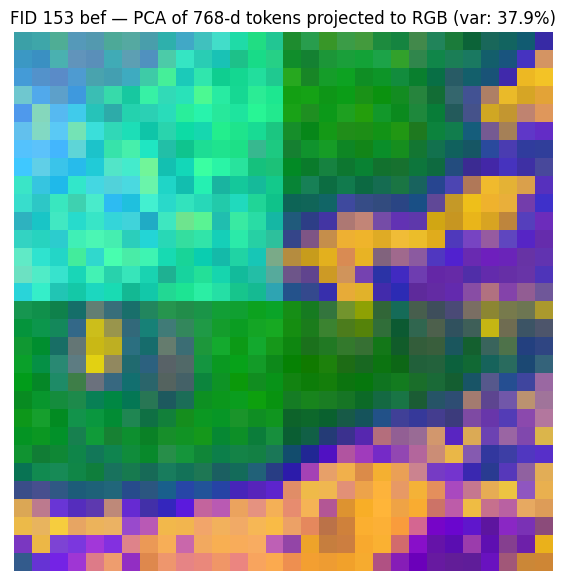

In [40]:
from sklearn.decomposition import PCA

# 1) Flatten the mosaic (H, W, 768) → (N_patches, 768).
flat = mosaic.reshape(-1, EMBED_DIM)

# 2) Fit PCA: find the 3 directions in 768-D space along which patches vary most.
pca = PCA(n_components=3)
projected = pca.fit_transform(flat)                  # (N_patches, 3)
print(f"Explained variance: {pca.explained_variance_ratio_}")
print(f"Cumulative:         {pca.explained_variance_ratio_.sum():.3f}")

# 3) Put the 3 components back into the spatial grid.
pca_rgb = projected.reshape(mosaic.shape[0], mosaic.shape[1], 3)

# 4) Per-channel min-max normalize to [0, 1] for RGB display.
for c in range(3):
    ch = pca_rgb[:, :, c]
    pca_rgb[:, :, c] = (ch - ch.min()) / (ch.max() - ch.min())

# 5) Plot.
plt.figure(figsize=(7, 7))
plt.imshow(pca_rgb, interpolation="nearest")
plt.title(f"FID {FID} {WINDOW} — PCA of 768-d tokens projected to RGB "
            f"(var: {pca.explained_variance_ratio_.sum():.1%})")
plt.axis("off")
plt.show()


### Embedding per disturbance centralized

In [41]:
import geopandas as gpd
from sklearn.decomposition import PCA

# ── 1) Cargar el polígono ─────────────────────────────────────────────────────
SHP_DIR = os.path.join(os.path.dirname(os.path.abspath("__file__")), "data_shp")
shp_path = os.path.join(SHP_DIR, "label_polygons.shp")
gdf = gpd.read_file(shp_path)
gdf["fid"] = gdf["fid"].astype(int).astype(str)

with rasterio.open(paths[0]) as src:                # CRS del mosaico = CRS de cualquier tile
    mosaic_crs = src.crs

poly_row = gdf[gdf["fid"] == str(FID)]
assert not poly_row.empty, f"No hay polígono para FID {FID}"
poly = poly_row.to_crs(mosaic_crs).geometry.iloc[0]

# ── 2) Centroide UTM → píxel en data_mosaic ──────────────────────────────────
cx, cy = poly.centroid.x, poly.centroid.y           # metros UTM
center_row = (y0 - cy) / 10.0                        # 10 m/píxel; y decrece hacia abajo
center_col = (cx - x0) / 10.0
print(f"Centroide polígono: UTM=({cx:.1f}, {cy:.1f})  pixel=({center_row:.1f}, {center_col:.1f})")

# ── 3) Top-left de un chunk 120x120 centrado en el centroide ─────────────────
#    Snap a múltiplo de 8 px para alinear con la rejilla de patches.
py = int(round(center_row - TILE_SIZE / 2))
px = int(round(center_col - TILE_SIZE / 2))
py = (py // PATCH_SIZE) * PATCH_SIZE
px = (px // PATCH_SIZE) * PATCH_SIZE


Centroide polígono: UTM=(-6980894.2, -958768.6)  pixel=(116.9, 70.6)


In [43]:
# Clip a los bordes del mosaico (por si el polígono está cerca del borde)
H, W = data_mosaic.shape[1], data_mosaic.shape[2]
py = max(0, min(py, H - TILE_SIZE))
px = max(0, min(px, W - TILE_SIZE))
print(f"Chunk top-left: row={py}, col={px}   (mosaico es {H}x{W} px)")

# ── 4) Recortar el chunk y validar ───────────────────────────────────────────
chunk = data_mosaic[:, py:py+TILE_SIZE, px:px+TILE_SIZE]
assert not np.isnan(chunk).any(), "El chunk centrado en el polígono cruza tiles faltantes."

# ── 5) Encode standalone (CROMA ve el chunk como una sola imagen) ────────────
chunk_t = torch.from_numpy(chunk).unsqueeze(0)
chunk_t = normalize(chunk_t, s2_mean, s2_std).to(device)
tokens_solo = encode(model, chunk_t, "optical")[0]    # (15, 15, 768)

# ── 6) Tokens correspondientes del mosaico ya cosido tile-a-tile ─────────────
ty, tx = py // PATCH_SIZE, px // PATCH_SIZE
tokens_stitched = mosaic[ty:ty+GRID_SIZE, tx:tx+GRID_SIZE, :]    # (15, 15, 768)

# ── 7) PCA conjunto + plot ───────────────────────────────────────────────────
a = tokens_solo.reshape(-1, EMBED_DIM)
b = tokens_stitched.reshape(-1, EMBED_DIM)
pca = PCA(n_components=3).fit(np.concatenate([a, b], axis=0))
solo_rgb     = pca.transform(a).reshape(GRID_SIZE, GRID_SIZE, 3)
stitched_rgb = pca.transform(b).reshape(GRID_SIZE, GRID_SIZE, 3)
stack = np.stack([solo_rgb, stitched_rgb])
for c in range(3):
    lo, hi = stack[..., c].min(), stack[..., c].max()
    solo_rgb[..., c]     = (solo_rgb[..., c]     - lo) / (hi - lo + 1e-10)
    stitched_rgb[..., c] = (stitched_rgb[..., c] - lo) / (hi - lo + 1e-10)

rgb_chunk = np.clip(chunk[[3, 2, 1]].transpose(1, 2, 0) / 10000, 0, 1)

Chunk top-left: row=56, col=8   (mosaico es 240x240 px)


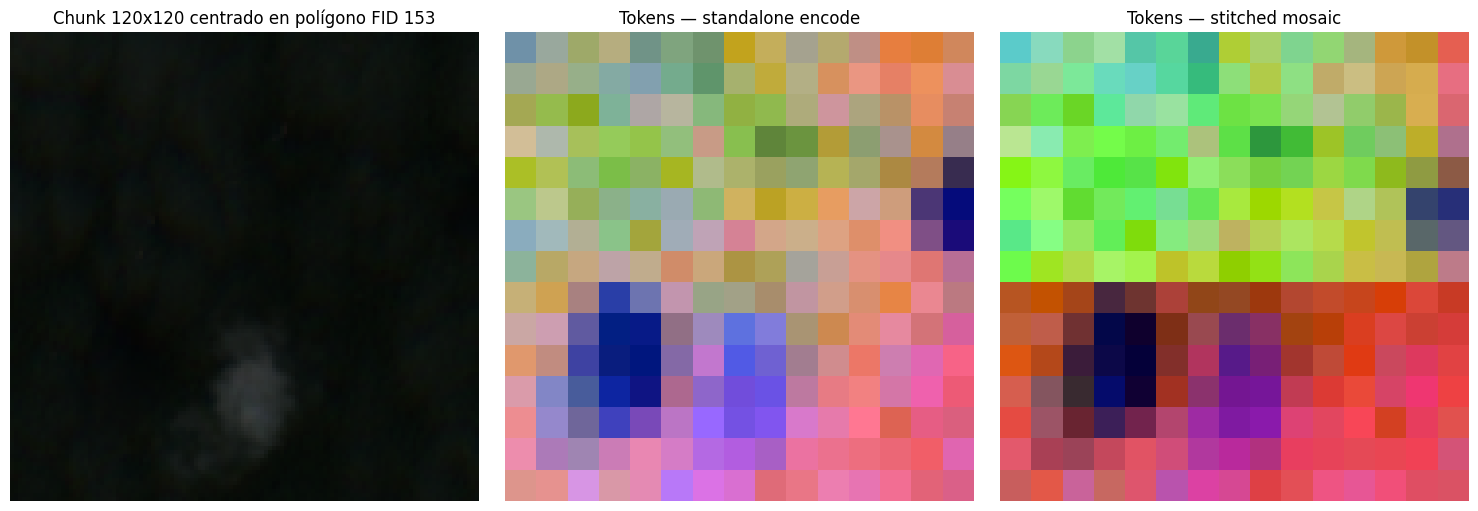

In [44]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(rgb_chunk)
axes[0].set_title(f"Chunk 120x120 centrado en polígono FID {FID}")
axes[1].imshow(solo_rgb, interpolation="nearest")
axes[1].set_title("Tokens — standalone encode")
axes[2].imshow(stitched_rgb, interpolation="nearest")
axes[2].set_title("Tokens — stitched mosaic")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()